In [1]:
import folium

# Pusat peta di tengah area AOI
lat_c = (-7.0683846 + -7.0230496) / 2
lon_c = (112.5058378 + 112.5963518) / 2

m = folium.Map(location=[lat_c, lon_c], zoom_start=12)

# Tandai area polygon AOI Kabupaten Gresik
folium.Rectangle(
    bounds=[[-7.0683846, 112.5058378], [-7.0230496, 112.5963518]],
    color="red",
    fill=True,
    fill_opacity=0.2,
    tooltip="Area Pengamatan Kabupaten Gresik (AOI Baru)",
).add_to(m)

m

In [2]:
import pandas as pd

# Menampilkan 5 data teratas CSV CH4
df_ch4 = pd.read_csv("./../data/csv/CH4_gresik_timeseries.csv")
df_ch4.head()

,date,CH4
0,2025-08-24,NaN
1,2025-08-25,NaN
2,2025-08-26,NaN
3,2025-08-27,NaN
4,2025-08-28,NaN


In [3]:
import pandas as pd

# Menampilkan 5 data teratas CSV CO
df_co = pd.read_csv("./../data/csv/CO_gresik_timeseries.csv")
df_co.head()

,date,CO
0,2025-08-24,0.031251
1,2025-08-25,0.034601
2,2025-08-26,NaN
3,2025-08-27,0.028711
4,2025-08-28,0.028990


In [4]:
import pandas as pd

# Menampilkan 5 data teratas CSV NO2
df_no2 = pd.read_csv("./../data/csv/NO2_gresik_timeseries.csv")
df_no2.head()

,date,NO2
0,2025-08-24,0.000081
1,2025-08-25,0.000134
2,2025-08-26,0.000069
3,2025-08-27,0.000056
4,2025-08-28,0.000080


In [5]:
import pandas as pd

# Menampilkan 5 data teratas CSV SO2
df_so2 = pd.read_csv("./../data/csv/SO2_gresik_timeseries.csv")
df_so2.head()

,date,SO2
0,2025-08-24,0.000271
1,2025-08-25,0.000586
2,2025-08-26,0.001380
3,2025-08-27,0.000094
4,2025-08-28,-0.000080


In [6]:
import pandas as pd

# Menampilkan 5 data teratas CSV gabungan 4 polutan
df_polutan = pd.read_csv("./../data/csv/polutan_gresik.csv")
df_polutan.head()

,date,CH4,CO,NO2,SO2
0,2025-08-24,NaN,0.031251,0.000081,0.000271
1,2025-08-25,NaN,0.034601,0.000134,0.000586
2,2025-08-26,NaN,NaN,0.000069,0.001380
3,2025-08-27,NaN,0.028711,0.000056,0.000094
4,2025-08-28,NaN,0.028990,0.000080,-0.000080


In [7]:
import pandas as pd
df = pd.read_csv("../data/csv/CH4_gresik_timeseries.csv")
ch4 = df["CH4"]
missingValueCH4 = ch4.isna().sum()
validValueCH4 = ch4.notna().sum()
print(f"Jumlah missing value pada data ch4 : {missingValueCH4}")
print(f"Jumlah data terisi (valid) pada data ch4 : {validValueCH4}")

Jumlah missing value pada data ch4 : 346
Jumlah data terisi (valid) pada data ch4 : 20


In [8]:
df = pd.read_csv("../data/csv/CO_gresik_timeseries.csv")
co = df["CO"]
missingValueCO = co.isna().sum()
validValueCO = co.notna().sum()
print(f"Jumlah missing value pada data co : {missingValueCO}")
print(f"Jumlah data terisi (valid) pada data co : {validValueCO}")

Jumlah missing value pada data co : 174
Jumlah data terisi (valid) pada data co : 192


In [9]:
df = pd.read_csv("../data/csv/NO2_gresik_timeseries.csv")
no2 = df["NO2"]
missingValueNO2 = no2.isna().sum()
validValueNO2 = no2.notna().sum()
print(f"Jumlah missing value pada data no2 : {missingValueNO2}")
print(f"Jumlah data terisi (valid) pada data no2 : {validValueNO2}")

Jumlah missing value pada data no2 : 166
Jumlah data terisi (valid) pada data no2 : 200


In [10]:
df = pd.read_csv("../data/csv/SO2_gresik_timeseries.csv")
so2 = df["SO2"]
missingValueSO2 = so2.isna().sum()
validValueSO2 = so2.notna().sum()
print(f"Jumlah missing value pada data so2 : {missingValueSO2}")
print(f"Jumlah data terisi (valid) pada data so2 : {validValueSO2}")

Jumlah missing value pada data so2 : 131
Jumlah data terisi (valid) pada data so2 : 235


In [11]:
import pandas as pd
from sklearn.ensemble import IsolationForest

df = pd.read_csv("../data/csv/CH4_gresik_timeseries.csv")
df_clean = df.dropna(subset=['CH4']).copy()

model = IsolationForest(contamination=0.05, random_state=42)
df_clean['outlier'] = model.fit_predict(df_clean[['CH4']])

normal_ch4 = df_clean[df_clean['outlier'] == 1]
outliers_ch4 = df_clean[df_clean['outlier'] == -1]

print(f"Jumlah outlier pada data ch4 : {len(outliers_ch4)}")
print(f"Jumlah tidak outlier (normal) pada data ch4 : {len(normal_ch4)}")

Jumlah outlier pada data ch4 : 1
Jumlah tidak outlier (normal) pada data ch4 : 19


In [12]:
import pandas as pd
from sklearn.ensemble import IsolationForest

df = pd.read_csv("../data/csv/CO_gresik_timeseries.csv")
df_clean = df.dropna(subset=['CO']).copy()

model = IsolationForest(contamination=0.05, random_state=42)
df_clean['outlier'] = model.fit_predict(df_clean[['CO']])

normal_co = df_clean[df_clean['outlier'] == 1]
outliers_co = df_clean[df_clean['outlier'] == -1]

print(f"Jumlah outlier pada data co : {len(outliers_co)}")
print(f"Jumlah tidak outlier (normal) pada data co : {len(normal_co)}")

Jumlah outlier pada data co : 10
Jumlah tidak outlier (normal) pada data co : 182


In [13]:
import pandas as pd
from sklearn.ensemble import IsolationForest

df = pd.read_csv("../data/csv/NO2_gresik_timeseries.csv")
df_clean = df.dropna(subset=['NO2']).copy()

model = IsolationForest(contamination=0.05, random_state=42)
df_clean['outlier'] = model.fit_predict(df_clean[['NO2']])

normal_no2 = df_clean[df_clean['outlier'] == 1]
outliers_no2 = df_clean[df_clean['outlier'] == -1]

print(f"Jumlah outlier pada data no2 : {len(outliers_no2)}")
print(f"Jumlah tidak outlier (normal) pada data no2 : {len(normal_no2)}")

Jumlah outlier pada data no2 : 10
Jumlah tidak outlier (normal) pada data no2 : 190


In [14]:
import pandas as pd
from sklearn.ensemble import IsolationForest

df = pd.read_csv("../data/csv/SO2_gresik_timeseries.csv")
df_clean = df.dropna(subset=['SO2']).copy()

model = IsolationForest(contamination=0.05, random_state=42)
df_clean['outlier'] = model.fit_predict(df_clean[['SO2']])

normal_so2 = df_clean[df_clean['outlier'] == 1]
outliers_so2 = df_clean[df_clean['outlier'] == -1]

print(f"Jumlah outlier pada data so2 : {len(outliers_so2)}")
print(f"Jumlah tidak outlier (normal) pada data so2 : {len(normal_so2)}")

Jumlah outlier pada data so2 : 12
Jumlah tidak outlier (normal) pada data so2 : 223


In [15]:
import pandas as pd

df = pd.read_csv("../data/csv/CH4_gresik_timeseries.csv")
df_clean = df.dropna(subset=['CH4']).copy()

mean_val = df_clean['CH4'].mean()
std_val = df_clean['CH4'].std()
cv_val = (std_val / mean_val) * 100

print(f"Rata-rata CH4 : {mean_val:.4f}")
print(f"Standar Deviasi CH4 : {std_val:.4f}")
print(f"Koefisien Variasi (CV) CH4 : {cv_val:.2f}%")

Rata-rata CH4 : 1887.2982
Standar Deviasi CH4 : 24.7520
Koefisien Variasi (CV) CH4 : 1.31%


In [16]:
import pandas as pd

df = pd.read_csv("../data/csv/CO_gresik_timeseries.csv")
df_clean = df.dropna(subset=['CO']).copy()

mean_val = df_clean['CO'].mean()
std_val = df_clean['CO'].std()
cv_val = (std_val / mean_val) * 100

print(f"Rata-rata CO : {mean_val:.6f}")
print(f"Standar Deviasi CO : {std_val:.6f}")
print(f"Koefisien Variasi (CV) CO : {cv_val:.2f}%")

Rata-rata CO : 0.028786
Standar Deviasi CO : 0.004084
Koefisien Variasi (CV) CO : 14.19%


In [17]:
import pandas as pd

df = pd.read_csv("../data/csv/NO2_gresik_timeseries.csv")
df_clean = df.dropna(subset=['NO2']).copy()

mean_val = df_clean['NO2'].mean()
std_val = df_clean['NO2'].std()
cv_val = (std_val / mean_val) * 100

print(f"Rata-rata NO2 : {mean_val:.6f}")
print(f"Standar Deviasi NO2 : {std_val:.6f}")
print(f"Koefisien Variasi (CV) NO2 : {cv_val:.2f}%")

Rata-rata NO2 : 0.000049
Standar Deviasi NO2 : 0.000034
Koefisien Variasi (CV) NO2 : 70.51%


In [18]:
import pandas as pd

df = pd.read_csv("../data/csv/SO2_gresik_timeseries.csv")
df_clean = df.dropna(subset=['SO2']).copy()

mean_val = df_clean['SO2'].mean()
std_val = df_clean['SO2'].std()
cv_val = (std_val / mean_val) * 100

print(f"Rata-rata SO2 : {mean_val:.6f}")
print(f"Standar Deviasi SO2 : {std_val:.6f}")
print(f"Koefisien Variasi (CV) SO2 : {cv_val:.2f}%")

Rata-rata SO2 : 0.000067
Standar Deviasi SO2 : 0.000241
Koefisien Variasi (CV) SO2 : 361.62%


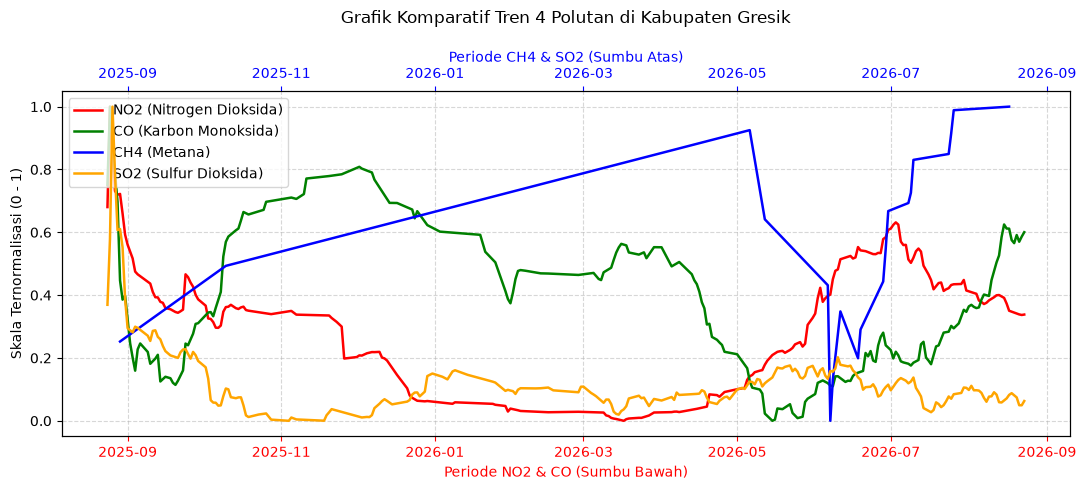

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load Data 4 Polutan
df_no2 = pd.read_csv("../data/csv/NO2_gresik_timeseries.csv").dropna(subset=['NO2'])
df_co  = pd.read_csv("../data/csv/CO_gresik_timeseries.csv").dropna(subset=['CO'])
df_ch4 = pd.read_csv("../data/csv/CH4_gresik_timeseries.csv").dropna(subset=['CH4'])
df_so2 = pd.read_csv("../data/csv/SO2_gresik_timeseries.csv").dropna(subset=['SO2'])

df_no2['date'] = pd.to_datetime(df_no2['date'])
df_co['date']  = pd.to_datetime(df_co['date'])
df_ch4['date'] = pd.to_datetime(df_ch4['date'])
df_so2['date'] = pd.to_datetime(df_so2['date'])

# 2. Smooth data dengan 30-day moving average (seperti Copernicus)
df_no2['NO2_smooth'] = df_no2['NO2'].rolling(window=30, min_periods=1).mean()
df_co['CO_smooth']   = df_co['CO'].rolling(window=30, min_periods=1).mean()
df_ch4['CH4_smooth'] = df_ch4['CH4'].rolling(window=30, min_periods=1).mean()
df_so2['SO2_smooth'] = df_so2['SO2'].rolling(window=30, min_periods=1).mean()

# 3. Normalisasi Min-Max (0 - 1)
for df, col in [(df_no2, 'NO2_smooth'), (df_co, 'CO_smooth'), (df_ch4, 'CH4_smooth'), (df_so2, 'SO2_smooth')]:
    df[col + '_norm'] = (df[col] - df[col].min()) / (df[col].max() - df[col].min())

# 4. Figure Dual X-Axis (Gaya Copernicus twiny())
fig, ax1 = plt.subplots(figsize=(11, 5), dpi=100)

# Sumbu Bawah: NO2 (Merah) & CO (Hijau)
(line1,) = ax1.plot(df_no2['date'], df_no2['NO2_smooth_norm'], color="r", label="NO2 (Nitrogen Dioksida)", linewidth=1.8)
(line2,) = ax1.plot(df_co['date'],  df_co['CO_smooth_norm'],   color="g", label="CO (Karbon Monoksida)", linewidth=1.8)

ax1.set_xlabel("Periode NO2 & CO (Sumbu Bawah)", color='r', fontsize=10)
ax1.set_ylabel("Skala Ternormalisasi (0 - 1)")
ax1.xaxis.label.set_color("r")
ax1.tick_params(axis="x", colors="r")
ax1.grid(True, linestyle='--', alpha=0.5)

# Sumbu Atas: CH4 (Biru) & SO2 (Oranye)
ax2 = ax1.twiny()
(line3,) = ax2.plot(df_ch4['date'], df_ch4['CH4_smooth_norm'], color="b", label="CH4 (Metana)", linewidth=1.8)
(line4,) = ax2.plot(df_so2['date'], df_so2['SO2_smooth_norm'], color="orange", label="SO2 (Sulfur Dioksida)", linewidth=1.8)

ax2.set_xlabel("Periode CH4 & SO2 (Sumbu Atas)", color='b', fontsize=10)
ax2.xaxis.label.set_color("b")
ax2.tick_params(axis="x", colors="b")

# Combine Legend
lines = [line1, line2, line3, line4]
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc="upper left")

plt.title("Grafik Komparatif Tren 4 Polutan di Kabupaten Gresik", pad=20)
plt.tight_layout()
plt.show()